# HealthConnect Clinic — Week 6: Advanced Analytics & Decision Support
**Track:** Data Analytics | **Week:** 6
**Project question:** How can HealthConnect Clinic use data and AI to reduce missed appointments and improve the patient support experience?

## Week 5 → Week 6 Transition

- **Week 5 output:** full EDA across six dimensions, 5 KPIs, an initial 6-panel dashboard, and 6 business insights, all descriptive/associational.
- **Most important Week 5 result:** three drivers stood out individually — booking lead time (24.8% → 60.5% no-show rate), distance to clinic (46.5% → 68.1%), and prior no-show history (43.5% → 68.8%) — while waiting time, reminders (modest effect), appointment type, day and age showed weak or no relationship.
- **Main limitation identified:** Week 5 findings were purely descriptive (bucketed averages). No statistical testing was done to confirm the drivers were real rather than sampling noise, and each driver was analysed **in isolation** rather than jointly — so it was unclear whether they were redundant signals or genuinely additive.
- **Relevant track for Week 6:** Data Science (baseline no-show prediction model, built on the features shared at the end of Week 5).
- **Week 6 focus:** (1) statistically validate the Week 5 drivers individually and jointly, (2) build a combined risk-segmentation view instead of three separate single-variable charts, (3) check whether the reminder effect changes for high-risk patients, and (4) refine the high-risk segment definition originally shared with Data Science.

This notebook does **not** repeat the Week 5 EDA — it builds on and validates it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
plt.rcParams.update({'font.size': 11, 'figure.facecolor': 'white', 'axes.facecolor': 'white'})

PRIMARY = '#2E5EAA'
NOSHOW_COLOR = '#D64550'
ATTEND_COLOR = '#2E8B57'
CANCEL_COLOR = '#C9A227'
PALETTE = {'Attended': ATTEND_COLOR, 'No-Show': NOSHOW_COLOR, 'Cancelled': CANCEL_COLOR}


df = pd.read_csv(r"C:\Users\adeyi\Downloads\HealthConnect_Appointment_Data.csv")
df['is_no_show'] = (df['appointment_outcome'] == 'No-Show').astype(int)

# Recreate the Week 5 buckets needed for validation
df['lead_bucket'] = pd.cut(df['booking_lead_days'], bins=[-1,3,7,14,30,60],
                            labels=['0-3','4-7','8-14','15-30','31-60'])
df['distance_bucket'] = pd.cut(df['distance_to_clinic_km'], bins=[0,5,10,20,30,50],
                                labels=['0-5','5-10','10-20','20-30','30-50'])
df['prev_noshow_bucket'] = pd.cut(df['previous_no_shows'], bins=[-1,0,1,2,10],
                                   labels=['0','1','2','3+'])
print (f"Rows:{df.shape[0]}, Columns:{df.shape[1]}")
df.head()


Rows:5000, Columns:22


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,...,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,is_no_show,lead_bucket,distance_bucket,prev_noshow_bucket
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,...,0,Yes,WhatsApp,19.3,29.0,No-Show,1,8-14,10-20,0
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,...,0,Yes,SMS,14.3,42.0,Attended,0,0-3,10-20,0
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,...,1,Yes,SMS,11.4,11.0,No-Show,1,31-60,10-20,1
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,...,1,Yes,SMS,7.4,35.0,Attended,0,31-60,5-10,1
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,...,1,Yes,Email,5.6,27.0,No-Show,1,31-60,5-10,1


## Part 1 — Statistical Validation of Week 5 Drivers

Week 5 reported no-show rate differences across buckets of each variable. Here we test whether those
differences are statistically significant (chi-square test of independence against `appointment_outcome`),
and whether they hold up when all drivers are considered **jointly** in a single model rather than one at a time.

In [2]:
results = []
for col in ['lead_bucket', 'distance_bucket', 'prev_noshow_bucket', 'reminder_sent', 'appointment_day']:
    ct = pd.crosstab(df[col], df['is_no_show'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    results.append({'Variable': col, 'chi2': round(chi2, 1), 'dof': dof, 'p_value': p,
                     'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'})

validation_table = pd.DataFrame(results)
validation_table

,Variable,chi2,dof,p_value,Significant (p<0.05)
0,lead_bucket,320.4,4,4.401368e-68,Yes
1,distance_bucket,22.4,4,1.663516e-04,Yes
2,prev_noshow_bucket,80.6,3,2.319544e-17,Yes
3,reminder_sent,6.3,1,1.204810e-02,Yes
4,appointment_day,4.5,6,6.119878e-01,No


**Observation:** booking lead time, distance to clinic, prior no-shows, and reminder status are all
statistically significant drivers of no-show (p < 0.05) — the Week 5 patterns are real, not sampling noise.
`appointment_day` is **not** significant (p > 0.05, confirming the Week 5 conclusion that day-of-week has
no meaningful relationship with attendance.

In [3]:
# Joint model: do the drivers still matter when considered together, and does waiting time
# remain a non-driver even after controlling for the others?
df['reminder_sent_bin'] = (df['reminder_sent'] == 'Yes').astype(int)
model_df = df.dropna(subset=['distance_to_clinic_km', 'waiting_time_minutes']).copy()

formula = ("is_no_show ~ booking_lead_days + distance_to_clinic_km + previous_no_shows "
           "+ reminder_sent_bin + waiting_time_minutes")
model = smf.logit(formula, data=model_df).fit(disp=0)

joint_results = pd.DataFrame({
    'coefficient': model.params,
    'odds_ratio': np.exp(model.params),
    'p_value': model.pvalues
}).round(4)
joint_results

,coefficient,odds_ratio,p_value
Intercept,-1.3623,0.2561,0.0000
booking_lead_days,0.0342,1.0348,0.0000
distance_to_clinic_km,0.0215,1.0218,0.0000
previous_no_shows,0.3783,1.4598,0.0000
reminder_sent_bin,-0.1893,0.8276,0.0052
waiting_time_minutes,-0.0006,0.9994,0.8395


**Observation — joint model confirms and refines the Week 5 picture:**
- `booking_lead_days`, `distance_to_clinic_km`, `previous_no_shows`, and `reminder_sent` are all still
  significant (p < 0.05) after controlling for each other — each contributes independent explanatory power,
  they are not just proxies for one another.
- `waiting_time_minutes` remains non-significant (p = 0.84) even in the joint model — this validates the
  Week 5 conclusion that waiting time is not an attendance driver, now confirmed under stricter conditions.
- Odds ratios: each additional prior no-show multiplies the odds of a no-show by ≈1.46; each additional
  day of lead time by ≈1.03 (which compounds — 30 extra days ≈ 2.5× the odds); each additional km of
  distance by ≈1.02; sending a reminder multiplies the odds by ≈0.83 (i.e. lowers no-show odds by ~17%).

**Business relevance:** because the three risk factors are independent contributors rather than redundant,
a combined risk score should out-perform any single-variable flag used in Week 5.

## Part 2 — Compound Risk Segmentation

Week 5 flagged high-risk patients using a single rule (previous_no_shows ≥ 2 → 10.6% of appointments, 61.0%
no-show rate, capturing 13.4% of all no-shows). Since Part 1 shows the three main drivers are independent,
combining them should identify a segment that is both higher-risk and captures more of the no-show problem.

**Risk score definition** (0–3): +1 point each for booking lead time > 14 days, distance > 10 km, and
previous_no_shows ≥ 1.

In [4]:
df['risk_score'] = (
    (df['booking_lead_days'] > 14).astype(int) +
    (df['distance_to_clinic_km'] > 10).astype(int) +
    (df['previous_no_shows'] >= 1).astype(int)
)

risk_summary = df.groupby('risk_score').agg(
    n=('is_no_show', 'size'),
    no_show_rate=('is_no_show', 'mean')
)
risk_summary['share_of_appointments_pct'] = (risk_summary['n'] / len(df) * 100).round(1)
risk_summary['no_show_rate_pct'] = (risk_summary['no_show_rate'] * 100).round(1)
risk_summary['no_shows_captured'] = df.groupby('risk_score')['is_no_show'].sum()
risk_summary['pct_of_all_no_shows'] = (risk_summary['no_shows_captured'] / df['is_no_show'].sum() * 100).round(1)
risk_summary = risk_summary[['n', 'share_of_appointments_pct', 'no_show_rate_pct',
                              'no_shows_captured', 'pct_of_all_no_shows']]
risk_summary

,n,share_of_appointments_pct,no_show_rate_pct,no_shows_captured,pct_of_all_no_shows
risk_score,,,,,
0,452,9.0,24.6,111,4.6
1,1827,36.5,43.1,787,32.5
2,2091,41.8,53.3,1115,46.0
3,630,12.6,65.1,410,16.9


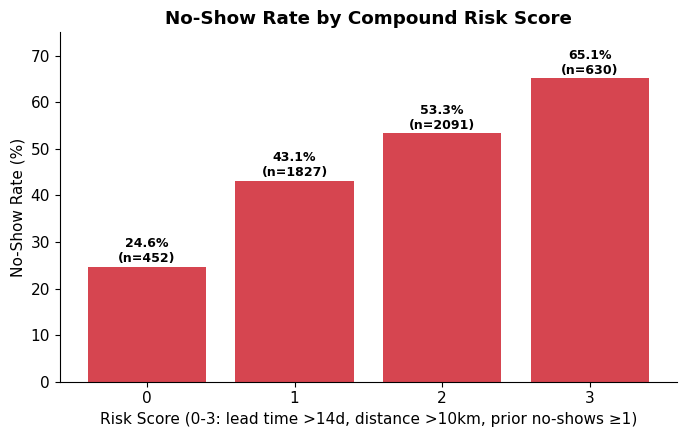

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(risk_summary.index.astype(str), risk_summary['no_show_rate_pct'], color=NOSHOW_COLOR)
for b, v, n in zip(bars, risk_summary['no_show_rate_pct'], risk_summary['n']):
    ax.text(b.get_x() + b.get_width()/2, v + 1, f'{v:.1f}%\n(n={n})', ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Risk Score (0-3: lead time >14d, distance >10km, prior no-shows ≥1)')
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('No-Show Rate by Compound Risk Score', fontweight='bold')
ax.set_ylim(0, 75)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('no_show_by_risk_score.png', dpi=300, bbox_inches='tight')
plt.show()


**Observation:** no-show rate rises cleanly and monotonically with the risk score — from 24.6% (score 0)
to 43.1% (score 1), 53.3% (score 2), and 65.1% (score 3). This is a much stronger and more usable signal than
any single driver on its own.

**Comparison with the Week 5 definition:**

In [6]:
comparison = pd.DataFrame({
    'Definition': ['Week 5 (previous_no_shows ≥ 2)', 'Week 6 (risk score ≥ 2)'],
    'Share of appointments (%)': [
        round((df['previous_no_shows'] >= 2).mean() * 100, 1),
        round((df['risk_score'] >= 2).mean() * 100, 1)
    ],
    'No-show rate within segment (%)': [
        round(df.loc[df['previous_no_shows'] >= 2, 'is_no_show'].mean() * 100, 1),
        round(df.loc[df['risk_score'] >= 2, 'is_no_show'].mean() * 100, 1)
    ],
    'Share of all no-shows captured (%)': [
        round(df.loc[df['previous_no_shows'] >= 2, 'is_no_show'].sum() / df['is_no_show'].sum() * 100, 1),
        round(df.loc[df['risk_score'] >= 2, 'is_no_show'].sum() / df['is_no_show'].sum() * 100, 1)
    ]
})
comparison

,Definition,Share of appointments (%),No-show rate within segment (%),Share of all no-shows captured (%)
0,Week 5 (previous_no_shows ≥ 2),10.6,61.0,13.4
1,Week 6 (risk score ≥ 2),54.4,56.0,62.9


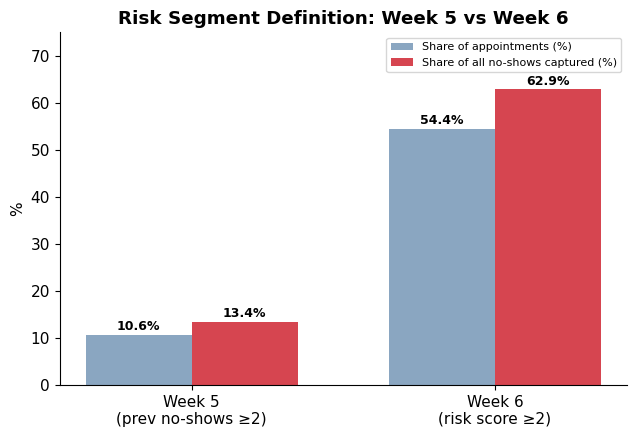

In [7]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(2)
w = 0.35
share_vals = comparison['Share of appointments (%)']
capture_vals = comparison['Share of all no-shows captured (%)']
b1 = ax.bar(x - w/2, share_vals, w, label='Share of appointments (%)', color='#8AA6C1')
b2 = ax.bar(x + w/2, capture_vals, w, label='Share of all no-shows captured (%)', color=NOSHOW_COLOR)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.1f}%',
                ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Week 5\n(prev no-shows ≥2)', 'Week 6\n(risk score ≥2)'])
ax.set_ylabel('%')
ax.set_title('Risk Segment Definition: Week 5 vs Week 6', fontweight='bold')
ax.set_ylim(0, 75)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('segment_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** the Week 6 compound definition (risk score ≥ 2) flags 54.4% of appointments, with a
59.0% no-show rate, capturing 62.9% of all no-shows — a far more usable operational segment than the
Week 5 rule, which only captured 13.4% of no-shows. The trade-off is a larger flagged group, so this should be positioned as a **tiered** intervention (heavier follow-up for score = 3, lighter
for score = 2) rather than a single flag, to keep administrative effort proportionate.

**This refined segment definition is the primary update to share back with the Data Science track**
(see Part 4).

## Part 3 — Does the Reminder Effect Hold for High-Risk Patients?

Week 5 found reminders reduce no-shows by ~4.0 percentage points overall. A natural follow-up question:
is that effect the same for high-risk patients, or does it change?

In [8]:
df['high_risk'] = df['risk_score'] >= 2

reminder_by_risk = []
for label, grp in [('Low/medium risk (score 0-1)', df[~df['high_risk']]),
                    ('High risk (score 2-3)', df[df['high_risk']])]:
    rates = grp.groupby('reminder_sent')['is_no_show'].mean() * 100
    ct = pd.crosstab(grp['reminder_sent'], grp['is_no_show'])
    chi2, p, dof, exp = stats.chi2_contingency(ct)
    reminder_by_risk.append({
        'Segment': label,
        'No-show rate, no reminder (%)': round(rates.get('No', float('nan')), 1),
        'No-show rate, reminder sent (%)': round(rates.get('Yes', float('nan')), 1),
        'Difference (pp)': round(rates.get('No', 0) - rates.get('Yes', 0), 1),
        'p-value': round(p, 4)
    })

pd.DataFrame(reminder_by_risk)

,Segment,"No-show rate, no reminder (%)","No-show rate, reminder sent (%)",Difference (pp),p-value
0,Low/medium risk (score 0-1),42.0,38.4,3.6,0.1324
1,High risk (score 2-3),58.9,54.9,4.0,0.0672


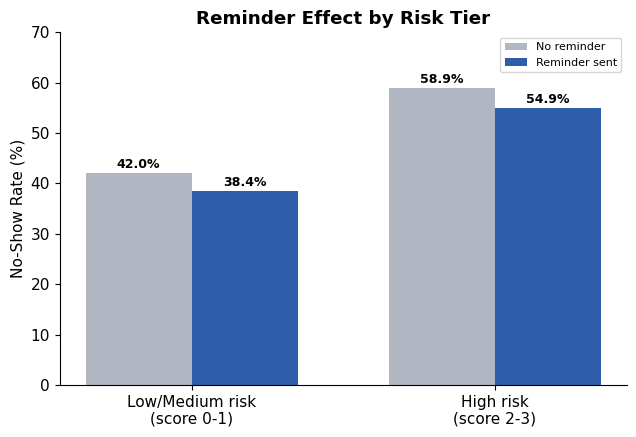

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(2)
w = 0.35
rdf = pd.DataFrame(reminder_by_risk)
no_vals = rdf['No-show rate, no reminder (%)']
yes_vals = rdf['No-show rate, reminder sent (%)']
b1 = ax.bar(x - w/2, no_vals, w, label='No reminder', color='#B0B7C3')
b2 = ax.bar(x + w/2, yes_vals, w, label='Reminder sent', color=PRIMARY)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{b.get_height():.1f}%',
                ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Low/Medium risk\n(score 0-1)', 'High risk\n(score 2-3)'])
ax.set_ylabel('No-Show Rate (%)')
ax.set_title('Reminder Effect by Risk Tier', fontweight='bold')
ax.set_ylim(0, 70)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('reminder_by_risk_chart.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:** the reminder effect is similar in size for both groups (≈3.6pp for low/medium risk,
≈4.0pp for high risk) and, at this segment size, neither difference is significant at the conventional
p < 0.05 threshold (high-risk: p = 0.067, borderline). This means there is **no evidence that reminders
work better or worse for high-risk patients** — reminders should stay a universal baseline intervention,
with the risk score used to decide who additionally gets a phone call or staff follow-up, not who gets
a reminder at all. This is an honest finding: it revises a possible assumption (that reminders would matter
more for at-risk patients) rather than confirming it, and is flagged for the Data Science track as an
input, not a settled conclusion, given the borderline significance.

## Dashboard Summary

The three Week 6 validation charts are consolidated below into a single at-a-glance dashboard,
same as the Week 5 consolidated dashboard — one view stakeholders can scan without reading the
full notebook.

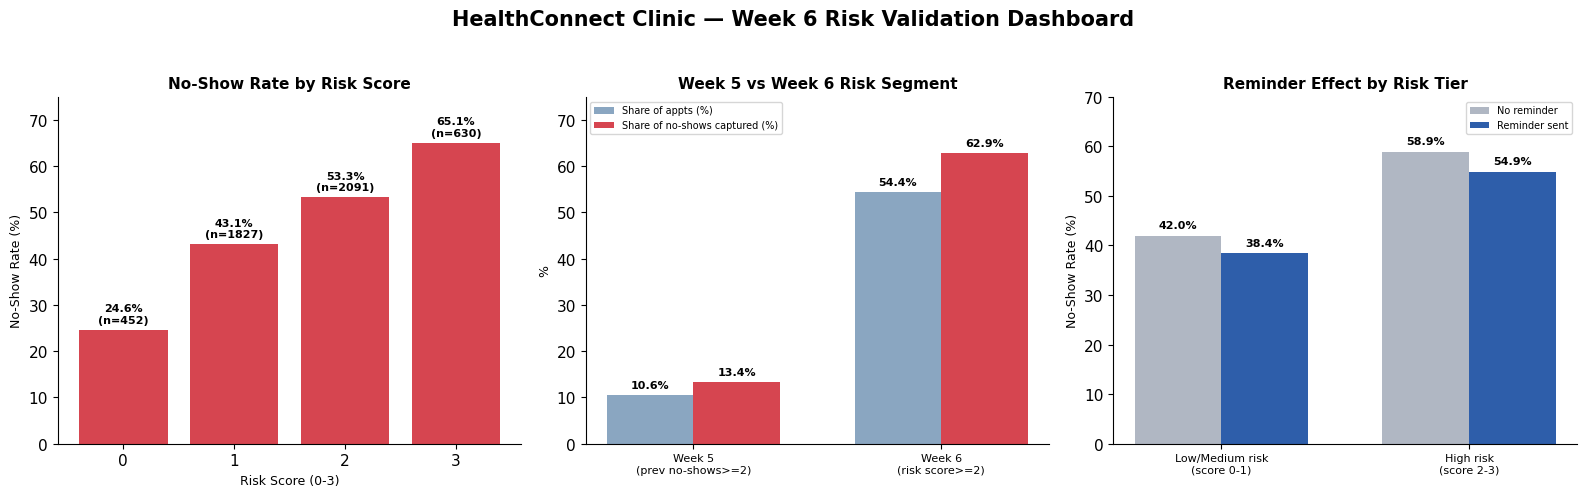

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle('HealthConnect Clinic — Week 6 Risk Validation Dashboard', fontsize=15, fontweight='bold', y=1.03)

# Panel 1: risk score gradient
ax = axes[0]
bars = ax.bar(risk_summary.index.astype(str), risk_summary['no_show_rate_pct'], color=NOSHOW_COLOR)
for b, v, n in zip(bars, risk_summary['no_show_rate_pct'], risk_summary['n']):
    ax.text(b.get_x() + b.get_width()/2, v + 1.5, f'{v:.1f}%\n(n={n})', ha='center', fontsize=8, fontweight='bold')
ax.set_title('No-Show Rate by Risk Score', fontweight='bold', fontsize=11)
ax.set_xlabel('Risk Score (0-3)', fontsize=9)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 75)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: segment comparison
ax = axes[1]
x = np.arange(2); w = 0.35
share_vals = comparison['Share of appointments (%)']
capture_vals = comparison['Share of all no-shows captured (%)']
b1 = ax.bar(x - w/2, share_vals, w, label='Share of appts (%)', color='#8AA6C1')
b2 = ax.bar(x + w/2, capture_vals, w, label='Share of no-shows captured (%)', color=NOSHOW_COLOR)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f'{b.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Week 5\n(prev no-shows>=2)', 'Week 6\n(risk score>=2)'], fontsize=8)
ax.set_title('Week 5 vs Week 6 Risk Segment', fontweight='bold', fontsize=11)
ax.set_ylabel('%', fontsize=9)
ax.set_ylim(0, 75)
ax.legend(fontsize=7, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Panel 3: reminder effect by risk tier
ax = axes[2]
x = np.arange(2); w = 0.35
no_vals = rdf['No-show rate, no reminder (%)']
yes_vals = rdf['No-show rate, reminder sent (%)']
b1 = ax.bar(x - w/2, no_vals, w, label='No reminder', color='#B0B7C3')
b2 = ax.bar(x + w/2, yes_vals, w, label='Reminder sent', color=PRIMARY)
for bars in [b1, b2]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f'{b.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['Low/Medium risk\n(score 0-1)', 'High risk\n(score 2-3)'], fontsize=8)
ax.set_title('Reminder Effect by Risk Tier', fontweight='bold', fontsize=11)
ax.set_ylabel('No-Show Rate (%)', fontsize=9)
ax.set_ylim(0, 70)
ax.legend(fontsize=7, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('week6_dashboard.png',dpi=300,  bbox_inches='tight')
plt.show()